In [ ]:
!pip install torch torchaudio asteroid pytorch-lightning

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.5/53.5 kB 7.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 9.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.4/156.4 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 63.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.2/519.2 kB 76.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.8/102.8 kB 15.1 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import re

folder = "/content/drive/MyDrive/DiplomLiza/content/A2model"

pattern = re.compile(
    r"epoch(\d+)_avg_loss(-?[0-9.]+)_val(-?[0-9.]+)"
)

data = []

for filename in os.listdir(folder):
    match = pattern.search(filename)
    if match:
        epoch = int(match.group(1))
        avg_loss = float(match.group(2))
        val_loss =float(match.group(3)[:-1])
        data.append((epoch, avg_loss, val_loss))

data.sort(key=lambda x: x[0])
print(data[0])
avg_losses = [x[1] for x in data]
val_losses = [x[2] for x in data]

with open("avg_loss.csv", "w") as f:
    f.write(",".join(str(avg_losses)))

with open("val_loss.csv", "w") as f:
    f.write(",".join(str(val_losses)))

(1, 26.18956004977226, 21.146575508117675)


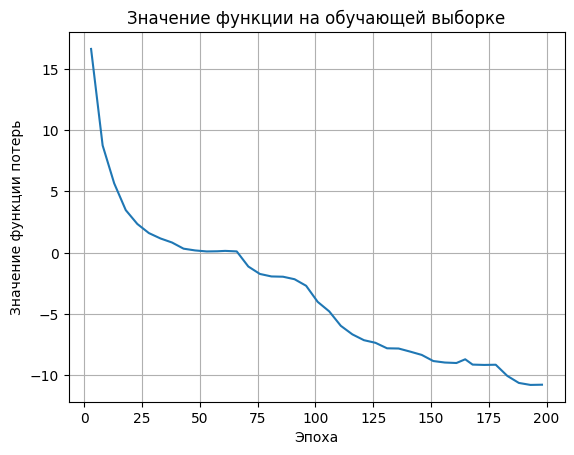

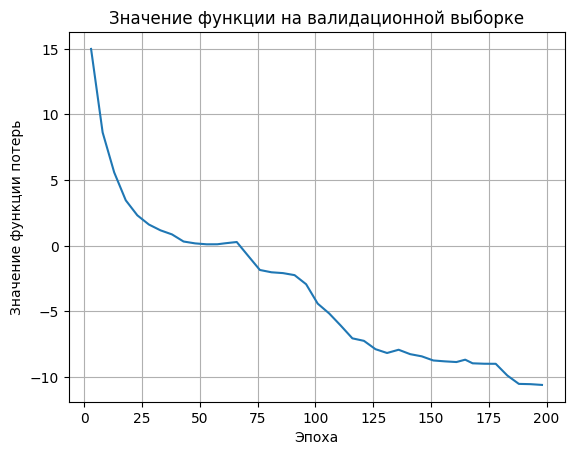

In [ ]:
import matplotlib.pyplot as plt

epochs = [x[0] for x in data]

def moving_avg_by_n(x, y, n=5):
    new_x = []
    new_y = []

    for i in range(0, len(x), n):
        chunk_x = x[i:i+n]
        chunk_y = y[i:i+n]

        if len(chunk_y) > 0:
            new_x.append(sum(chunk_x) / len(chunk_x))
            new_y.append(sum(chunk_y) / len(chunk_y))

    return new_x, new_y

epochs_avg, avg_loss_smooth = moving_avg_by_n(epochs, avg_losses, 5)
_, val_loss_smooth = moving_avg_by_n(epochs, val_losses, 5)

plt.figure()
plt.plot(epochs_avg, avg_loss_smooth)
plt.xlabel("Эпоха")
plt.ylabel("Значение функции потерь")
plt.title("Значение функции на обучающей выборке")
plt.grid()
plt.show()

plt.figure()
plt.plot(epochs_avg, val_loss_smooth)
plt.xlabel("Эпоха")
plt.ylabel("Значение функции потерь")
plt.title("Значение функции на валидационной выборке")
plt.grid()
plt.show()

In [ ]:
!pip install pydub

In [ ]:
import os
import random
from pydub import AudioSegment
def load_all(folder):
  files = [f for f in os.listdir(folder) if f.endswith((".wav", ".mp3", ".ogg"))]
  all_audio = AudioSegment.empty()
  for file in files:
      audio = AudioSegment.from_file(os.path.join(folder, file))
      if audio.channels > 1:
          audio = audio.split_to_mono()[0]
      all_audio += audio
  return all_audio

/usr/local/lib/python3.12/dist-packages/pydub/utils.py:300: SyntaxWarning: invalid escape sequence '\('
  m = re.match('([su]([0-9]{1,2})p?) \(([0-9]{1,2}) bit\)$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:301: SyntaxWarning: invalid escape sequence '\('
  m2 = re.match('([su]([0-9]{1,2})p?)( \(default\))?$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:310: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(flt)p?( \(default\))?$', token):
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:314: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(dbl)p?( \(default\))?$', token):


In [ ]:
import os
import random
from pydub import AudioSegment

In [ ]:
DRONE_AUDIO = AudioSegment.from_file("/content/merged_5sn.mp3")
DRONE_AUDIO_TEST = AudioSegment.from_file("/content/merged_5sn.mp3")
NOIZE_AUDIO=load_all("/content/noize")

In [ ]:
DRONE_AUDIO=DRONE_AUDIO.split_to_mono()[0]
print("DRONE_AUDIO Duration:", len(DRONE_AUDIO))
print("DRONE_AUDIO Frame rate:", DRONE_AUDIO.frame_rate)
print("DRONE_AUDIO Channels:",DRONE_AUDIO.channels)
DRONE_AUDIO=DRONE_AUDIO.split_to_mono()[0]

DRONE_AUDIO Duration: 840000
DRONE_AUDIO Frame rate: 16000
DRONE_AUDIO Channels: 1


In [ ]:
NOIZE_AUDIO=NOIZE_AUDIO.set_frame_rate(16000)
print("NOIZE_AUDIO Duration:", len(NOIZE_AUDIO))
print("NOIZE_AUDIO Frame rate:", NOIZE_AUDIO.frame_rate)
print("NOIZE_AUDIO Channels:",NOIZE_AUDIO.channels)

NOIZE_AUDIO Duration: 10124966
NOIZE_AUDIO Frame rate: 16000
NOIZE_AUDIO Channels: 1


In [ ]:
from google.colab import files
import shutil
def get_dataset(path_dataset, name):
    shutil.make_archive(name, 'zip', path_dataset)
    files.download(f"{name}.zip")

In [ ]:
!pip install pydub
!apt-get install -y ffmpeg

from pydub import AudioSegment
import os

def combine_dataset(path_dataset, name):
    wav_files = [f for f in os.listdir(path_dataset) if f.endswith('.wav')]
    wav_files.sort()

    if not wav_files:
        print("Нет WAV файлов в папке")
        return

    combined = AudioSegment.empty()

    for file in wav_files:
        audio = AudioSegment.from_wav(os.path.join(path_dataset, file))
        combined += audio

    combined.export(name + ".wav", format="wav")

    print(f"Все WAV успешно объединены в: {name}.wav")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.


In [ ]:
combine_dataset(path_dataset="/content/DroneAudioDataset/Binary_Drone_Audio/yes_drone",
                name="drone")

Все WAV успешно объединены в: drone.wav


In [ ]:
# Cоловей
DRONE_PATH="/content/drone_dataset"
DRONE_EXAMPLE_FILE="/content/test_drone.wav"
DRONE_EXAMPLE_FILE_FULL="/content/drone.wav"

# Шум
NOISE_PATH="/content/noize"
NOISE_EXAMPLE_FILE="/content/test_noize.wav"
NOISE_EXAMPLE_FILE_FULL="/content/combined_noize.wav"

# Комбинация
COMBINED_PATH="/content/combined_dataset"
COMBINED_EXAMPLE_FILE="/content/test_combined.mp3"

DENOIZED="/content/denoised.wav"

COUNT=500

In [ ]:
from pydub import AudioSegment
def save_mp3(audio, sr, filename):
    if np.max(np.abs(audio)) > 0:
        audio = audio / np.max(np.abs(audio))
    audio_int16 = (audio * 32767).astype(np.int16)
    seg = AudioSegment(
        audio_int16.tobytes(),
        frame_rate=sr,
        sample_width=2,
        channels=1
    )
    seg.export(filename, format="mp3", bitrate="192k")

In [ ]:
from pydub import AudioSegment

def make_ch_audio(channels: list, output_path):
    if len(channels) < 1:
        raise ValueError("Список каналов пуст")
    min_len = min(len(ch) for ch in channels)
    channels = [ch[:min_len] for ch in channels]
    multi = AudioSegment.from_mono_audiosegments(*channels)
    multi.export(output_path, format="wav")
    return output_path

In [ ]:
from pydub import AudioSegment

def split_to_sequence(input_path):
    audio = AudioSegment.from_file(input_path)
    if audio.channels < 2:
        raise ValueError("Файл не многоканальный")
    channels = audio.split_to_mono()
    combined = AudioSegment.empty()
    for ch in channels:
        combined += ch
    return combined

In [ ]:
from pydub import AudioSegment
def sequence_to_multich(input_path, output_path, num_channels=3):
    audio = AudioSegment.from_file(input_path)
    if num_channels < 1:
        raise ValueError("Количество каналов должно быть >= 1")
    part_len = len(audio) // num_channels

    channels = []
    for i in range(num_channels):
        start = i * part_len
        end = (i + 1) * part_len if i < num_channels - 1 else len(audio)
        channels.append(audio[start:end])

    multi = AudioSegment.from_mono_audiosegments(*channels)
    print("chanels:"+multi.channels)
    return multi

In [ ]:
import librosa
import numpy as np
import random
import soundfile as sf

def get_random_segment(audio, fs, sec=150):
    segment_length = sec * fs
    if len(audio) <= segment_length:
        return audio
    start = random.randint(0, len(audio) - segment_length)
    end = start + segment_length
    segment = audio[start:end]
    return segment

def get_random_segments(combined, noize,clean, sec=1, count=3):
    segments_clean = []
    segments_noize = []
    segments_combined = []
    segment_length = sec * 1000
    if len(combined) < segment_length or len(noize) < segment_length or len(clean) < segment_length :
        raise ValueError("Audio is shorter than segment length")
    for i in range(count):
        start = random.randint(0, len(combined) - segment_length)
        end = start + segment_length
        segments_clean.append(clean[start:end])
        segments_noize.append(noize[start:end])
        segments_combined.append(combined[start:end])
    return segments_combined, segments_noize, segments_clean

In [ ]:
import numpy as np

def audiosegment_to_array(seg):
    return np.array(seg.get_array_of_samples())

def array_to_audiosegment(arr, seg):
    return seg._spawn(arr.astype(np.int16).tobytes())

def combined_audio(clean_audio, noise):
    clean_arr = audiosegment_to_array(clean_audio).astype(np.float32)
    noise_arr = audiosegment_to_array(noise).astype(np.float32)
    min_len = min(len(clean_arr), len(noise_arr))
    clean_arr = clean_arr[:min_len]
    noise_arr = noise_arr[:min_len]

    clean_arr /= (np.max(np.abs(clean_arr)) + 1e-8)
    noise_arr /= (np.max(np.abs(noise_arr)) + 1e-8)

    scale = np.random.rand()
    combined = (1-scale)*clean_arr + scale * noise_arr

    combined /= (np.max(np.abs(combined)) + 1e-8)

    combined = (combined * 32767).astype(np.int16)

    return array_to_audiosegment(combined, clean_audio)

In [ ]:
import librosa
import soundfile as sf
import os
def generateSegment(from_f, to, sec=5, sr=16000):
    audio, _ = librosa.load(from_f, sr=sr)
    audio = get_random_segment(audio, sr, sec)
    save_mp3(audio, sr, to)


In [ ]:
import librosa
import soundfile as sf
import os

def generate(fcount=0 ,count=500, sec=1,ch=3, sr=16000,
             solovey_out_dir=DRONE_PATH,
             combined_out_dir=COMBINED_PATH,
             noisy_out_dir=NOISE_PATH):
    os.makedirs(solovey_out_dir, exist_ok=True)
    os.makedirs(combined_out_dir, exist_ok=True)
    os.makedirs(noisy_out_dir, exist_ok=True)
    noisy_all=NOIZE_AUDIO
    clean_all=DRONE_AUDIO

    for num in range(fcount, count):
        noisy = get_random_segment(noisy_all, sr, sec*ch*2)
        clean = get_random_segment(clean_all, sr, sec*ch*2)

        combined = combined_audio(clean, noisy)
        combined_ch, noisy_ch,clean_ch= get_random_segments(combined, noisy,clean,sec=1, count=3)

        # сохраняем mp3
        filename = os.path.join(solovey_out_dir, f"ex_{num}.wav")
        make_ch_audio(channels=clean_ch, output_path=filename)
        print(f"Сохранено: {filename}")
        filename = os.path.join(combined_out_dir, f"ex_{num}.wav")
        make_ch_audio(channels=combined_ch, output_path=filename)
        print(f"Сохранено: {filename}")
        filename = os.path.join(noisy_out_dir, f"ex_{num}.wav")
        make_ch_audio(channels=noisy_ch, output_path=filename)
        print(f"Сохранено: {filename}")

In [ ]:
generate(fcount=8000 ,count=10000, sec=1,ch=3, sr=16000,
             solovey_out_dir=DRONE_PATH,
             combined_out_dir=COMBINED_PATH,
             noisy_out_dir=NOISE_PATH)

Выходные данные были обрезаны до нескольких последних строк (5000).
Сохранено: /content/combined_dataset/ex_8333.wav
Сохранено: /content/noize/ex_8333.wav
Сохранено: /content/drone_dataset/ex_8334.wav
Сохранено: /content/combined_dataset/ex_8334.wav
Сохранено: /content/noize/ex_8334.wav
Сохранено: /content/drone_dataset/ex_8335.wav
Сохранено: /content/combined_dataset/ex_8335.wav
Сохранено: /content/noize/ex_8335.wav
Сохранено: /content/drone_dataset/ex_8336.wav
Сохранено: /content/combined_dataset/ex_8336.wav
Сохранено: /content/noize/ex_8336.wav
Сохранено: /content/drone_dataset/ex_8337.wav
Сохранено: /content/combined_dataset/ex_8337.wav
Сохранено: /content/noize/ex_8337.wav
Сохранено: /content/drone_dataset/ex_8338.wav
Сохранено: /content/combined_dataset/ex_8338.wav
Сохранено: /content/noize/ex_8338.wav
Сохранено: /content/drone_dataset/ex_8339.wav
Сохранено: /content/combined_dataset/ex_8339.wav
Сохранено: /content/noize/ex_8339.wav
Сохранено: /content/drone_dataset/ex_8340.wav
С

In [ ]:
audio = AudioSegment.from_file("/content/combined_dataset/ex_8000.wav")
print(audio.channels)

3


In [ ]:
import librosa
import IPython.display as ipd
audio, fs = librosa.load("/content/combined_solovey10.mp3", sr=None)
ipd.Audio(audio, rate=fs)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
import torch

def spectral_denoise(audio, n_fft=1024, hop_length=512):
    if audio.dim() > 1:
        audio = audio.mean(dim=0)

    device = audio.device
    window = torch.hann_window(n_fft).to(device)
    D = torch.stft(
        audio,
        n_fft=n_fft,
        hop_length=hop_length,
        window=window,
        return_complex=True
    )

    magnitude = torch.abs(D)
    phase = torch.angle(D)

    threshold = magnitude.mean() * 1.5
    magnitude_filtered = magnitude.clone()
    magnitude_filtered[magnitude < threshold] = 0

    D_filtered = magnitude_filtered * torch.exp(1j * phase)

    audio_out = torch.istft(
        D_filtered,
        n_fft=n_fft,
        hop_length=hop_length,
        window=window,
        length=audio.shape[-1]
    )

    return audio_out

In [ ]:
import os
import torch
import torchaudio
from torch.utils.data import Dataset

class DroneDataset(Dataset):
    def __init__(self, combined_files=COMBINED_PATH, noisy_files=NOISE_PATH, clean_files=DRONE_PATH, start=0, len=100):
        self.noisy_files = noisy_files
        self.combined_files = combined_files
        self.clean_files=clean_files
        self.len=len
        self.start=start

    def split_to_sequence(self, input_path):
        audio = AudioSegment.from_file(input_path)
        if audio.channels < 2:
            raise ValueError("Файл не многоканальный")
        channels = audio.split_to_mono()
        combined = AudioSegment.empty()
        for ch in channels:
            combined += ch
        arr = np.array(combined.get_array_of_samples())
        return torch.tensor(arr, dtype=torch.float32), combined.frame_rate

    def __len__(self):
        return self.len

    def __getitem__(self, idx):
        noisy_path=self.noisy_files+f"/ex_{idx+self.start}.wav"
        clean_path=self.clean_files+f"/ex_{idx+self.start}.wav"
        combined_path=self.combined_files+f"/ex_{idx+self.start}.wav"
        clean, sr=self.split_to_sequence(clean_path)
        noisy, sr =self.split_to_sequence(noisy_path)
        combine, sr =self.split_to_sequence(combined_path)
        return combine.squeeze(), torch.stack([clean.squeeze(), noisy.squeeze()], dim=0)

In [ ]:
from torch.utils.data import DataLoader
dataset_tarin = DroneDataset(len=8000)
loader_train = DataLoader(dataset_tarin, batch_size=10, shuffle=True)
dataset_test = DroneDataset(start=8000, len=2000)
loader_test = DataLoader(dataset_test,
                          batch_size=10, shuffle=True)

In [ ]:
def save_model(model_step, model_name):
    torch.save(model_step.state_dict(), model_name)
    torch.save(model_step.state_dict(), '/content/drive/MyDrive/DiplomLiza'+model_name)

In [ ]:
def save_loss(filepath, number):
    try:
        with open(filepath, "r") as f:
            content = f.read().strip()
    except FileNotFoundError:
        content = ""

    if content:
        content += f",{number}"
    else:
        content = str(number)

    with open(filepath, "w") as f:
        f.write(content)
    with open('/content/drive/MyDrive/DiplomLiza'+filepath, "w") as f:
        f.write(content)

In [ ]:
def load_loss(filepath):
    try:
        with open(filepath, "r") as f:
            content = f.read().strip()
    except FileNotFoundError:
        return []

    if not content:
        return []

    return [np.float256(x) for x in content.split(",")]

In [ ]:
MODEL_DIR = "/content/A2model/"
LOSS="/content/A2loss/"
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs("/content/drive/MyDrive/DiplomLiza"+MODEL_DIR, exist_ok=True)
os.makedirs(LOSS, exist_ok=True)
os.makedirs("/content/drive/MyDrive/DiplomLiza"+LOSS, exist_ok=True)

In [ ]:
def get_model(device, need_load=False):
  model = model = model = torchaudio.models.ConvTasNet(num_sources=2).to(device)

  if need_load :
     state_dict = torch.load(MODEL_PATH, map_location="cpu")
     # переносим на TPU
     model.load_state_dict(state_dict)
     model.to(device)
  return model

In [ ]:
from asteroid.losses import pairwise_neg_sisdr,PITLossWrapper
def validate(model, test_loader):
    model.eval()
    val_loss = 0
    loss_fn = pairwise_neg_sisdr

    with torch.no_grad():
        for batch_idx, batch  in enumerate(test_loader, 1):
            noisy, clean =batch[0], batch[1]
            print(f"test batch {batch_idx}")

            noisy = noisy.unsqueeze(1).to(device)
            clean = clean.to(device)

            pred = model(noisy)

            loss = loss_fn(pred[:, 0:1, :], clean[:, 0:1, :]).mean()
            print(loss.item())
            del noisy, clean, pred
            val_loss += loss.item()

    val_loss /= len(test_loader)
    return val_loss

In [ ]:
from asteroid.losses import pairwise_neg_sisdr,PITLossWrapper
def train(model, device, last_epoch=0, epoch=200, need_save=True, dataset_size=400):
    global REGENERATE

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)
    loss_fn = pairwise_neg_sisdr
    loss_list_train = []
    loss_list_test = []

    for ep in range(last_epoch, epoch):
        if REGENERATE:
            print(f"REGENERATE")
            generate(fcount=0 ,count=8000, sec=1,ch=3, sr=16000,
             solovey_out_dir=DRONE_PATH,
             combined_out_dir=COMBINED_PATH,
             noisy_out_dir=NOISE_PATH)

        model.train()
        epoch_loss = 0.0
        print(f"Start train epoch {ep+1}")
        for batch_idx, batch  in enumerate(loader_train, 1):
            noisy, clean =batch[0], batch[1]
            print(f"epoch {ep+1} batch {batch_idx}")

            optimizer.zero_grad()
            noisy = noisy.unsqueeze(1).to(device)
            clean = clean.to(device)

            pred = model(noisy)
            loss = loss_fn(pred[:, 0:1, :], clean[:, 0:1, :]).mean()
            print(loss.item())
            loss.backward()

            optimizer.step()

            del noisy, clean, pred
            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(loader_train)
        loss_list_train.append(avg_loss)
        validate_loss=validate(model, loader_test)
        loss_list_test.append(validate_loss)

        if need_save:
            MODEL_PATH=f"{MODEL_DIR}/model_epoch{ep+1}_avg_loss{avg_loss}_val{validate_loss}.ptx"
            save_model(model, f"{MODEL_DIR}/model_epoch{ep+1}_avg_loss{avg_loss}_val{validate_loss}.ptx")

        print(f"Epoch {ep+1} finished. Avg Loss: {avg_loss}. Avg Loss:{validate_loss}")
        save_loss("/content/A2loss/avg.txt", avg_loss)
        save_loss("/content/A2loss/val.txt", validate_loss)

    return model, loss_list_train, loss_list_test

In [ ]:
!rm -rf "/content/combined_dataset"
!rm -rf "/content/noize"
!rm -rf "/content/drone_dataset"

In [ ]:
!rm -rf "/content/Amodel"
!rm -rf "/content/Aloss"

In [ ]:
import torch
MODEL_PATH = "/content/A2model/model_epoch184_avg_loss-10.632706117918715_val-10.536394548341631.ptx"
STOP_TRAINING=False
REGENERATE=True
print("run")
torch.cuda.empty_cache()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = get_model(device, need_load=True)
model, loss_list_train, loss_list_test = train(model=model, device=device, last_epoch=184)

Выходные данные были обрезаны до нескольких последних строк (5000).
Сохранено: /content/combined_dataset/ex_6594.wav
Сохранено: /content/noize/ex_6594.wav
Сохранено: /content/drone_dataset/ex_6595.wav
Сохранено: /content/combined_dataset/ex_6595.wav
Сохранено: /content/noize/ex_6595.wav
Сохранено: /content/drone_dataset/ex_6596.wav
Сохранено: /content/combined_dataset/ex_6596.wav
Сохранено: /content/noize/ex_6596.wav
Сохранено: /content/drone_dataset/ex_6597.wav
Сохранено: /content/combined_dataset/ex_6597.wav
Сохранено: /content/noize/ex_6597.wav
Сохранено: /content/drone_dataset/ex_6598.wav
Сохранено: /content/combined_dataset/ex_6598.wav
Сохранено: /content/noize/ex_6598.wav
Сохранено: /content/drone_dataset/ex_6599.wav
Сохранено: /content/combined_dataset/ex_6599.wav
Сохранено: /content/noize/ex_6599.wav
Сохранено: /content/drone_dataset/ex_6600.wav
Сохранено: /content/combined_dataset/ex_6600.wav
Сохранено: /content/noize/ex_6600.wav
Сохранено: /content/drone_dataset/ex_6601.wav
С